# 08 — Чёрный лебедь: каскадный обвал за минуты

Наша кривая гладкая (DD −6%), но она НИКОГДА не встречала системный каскад.
В каскаде алгоритм делает худшее: триггер −7%/15м срабатывает на всех монетах
разом, scale-in добирает в падающий нож, держит 4ч БЕЗ стопа.

**Что считаем:**
1. Худшие реальные дни в выборке 2024-26 (как алго себя вёл).
2. Синтетические каскады через РЕАЛЬНЫЙ scale-in код (медленный/flash/V/LUNA).
3. Портфель + плечо: потеря за день лебедя, граница ликвидации.
4. Вероятность: база крипто-каскадов (COVID/LUNA/FTX — все ВНЕ наших данных).

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path
WIN=15;H=240;COOLDOWN=10;MIN_GAP=3;N_MAX=10;FEE=0.00075;THR=0.07

# ---- 1. worst REAL days in-sample ----
D=pd.read_parquet(Path("_out")/"dump_trades.parquet")
D["day"]=pd.to_datetime(D.entry).dt.date
g=D.groupby("day").agg(n=("pnl","size"),avg=("pnl","mean"),total=("pnl","sum"),
                       worst=("pnl","min"))
g=g[g.n>=10]   # days with many concurrent dumps = mini-swan candidates
print("=== WORST in-sample days by mean per-trade PnL (n>=10 dumps that day) ===")
for day,r in g.sort_values("avg").head(8).iterrows():
    print(f"  {day}  n={int(r.n):3d}  mean {r.avg*100:+6.2f}%  worst {r.worst*100:+6.1f}%  (sum {r.total*100:+.0f}%)")
print("\n=== BUSIEST days (most simultaneous dumps = correlation proxy) ===")
for day,r in g.sort_values("n",ascending=False).head(6).iterrows():
    print(f"  {day}  n={int(r.n):3d}  mean {r.avg*100:+6.2f}%  worst {r.worst*100:+6.1f}%")

=== WORST in-sample days by mean per-trade PnL (n>=10 dumps that day) ===
  2025-02-02  n= 15  mean -11.02%  worst  -18.9%  (sum -165%)
  2026-04-19  n= 17  mean  -5.85%  worst  -19.1%  (sum -99%)
  2024-02-24  n= 11  mean  -5.48%  worst  -32.1%  (sum -60%)
  2026-04-17  n= 15  mean  -1.98%  worst  -17.8%  (sum -30%)
  2025-11-08  n= 19  mean  -1.95%  worst  -13.4%  (sum -37%)
  2025-10-11  n= 11  mean  -1.93%  worst  -15.9%  (sum -21%)
  2024-12-18  n= 86  mean  -1.69%  worst   -4.9%  (sum -145%)
  2024-12-04  n= 19  mean  -1.32%  worst  -11.8%  (sum -25%)

=== BUSIEST days (most simultaneous dumps = correlation proxy) ===
  2025-10-10  n=319  mean +16.65%  worst  -23.5%
  2024-08-05  n=257  mean  +0.32%  worst   -8.1%
  2024-04-12  n=217  mean  +0.96%  worst  -15.1%
  2024-03-05  n=205  mean  +6.56%  worst  -20.1%
  2024-04-13  n=196  mean  +6.54%  worst   -5.4%
  2024-01-03  n=185  mean  +7.70%  worst  -53.9%


In [2]:
# ---- 2. synthetic cascade paths through the REAL scale-in logic ----
def clusters(c,thr):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=r<=-thr; out=[]; i=WIN; n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        start=i;last_true=i;tr=[i];lastt=i;falses=0;j=i+1
        while j<n:
            if cond[j]:
                last_true=j;falses=0
                if j-lastt>=MIN_GAP and len(tr)<N_MAX: tr.append(j);lastt=j
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((start,last_true,tr)); i=last_true+COOLDOWN+1
    return out

def scalein_pnl(c):
    # first cluster's scale-in position: avg entry + exit at cluster_end+H (or last bar)
    cl=clusters(c,THR)
    if not cl: return None
    st,en,tr=cl[0]; n=len(c); ex=min(en+1+H,n-1)
    prices=np.array([c[t+1] for t in tr if t+1<n])
    ws=np.arange(1,len(prices)+1,dtype=float); ws/=ws.sum()
    avg=(ws*prices).sum()
    return dict(ntr=len(prices), avg_entry=avg/c[0]-1, exit_px=c[ex]/c[0]-1,
                pnl=c[ex]/avg-1-2*FEE, exit_min=ex)

PRE=200  # flat pre-roll so trailing-15m window is defined
def path(seg):
    return np.concatenate([np.ones(PRE), seg])

def lin(depth, mins):  # linear crash to (1-depth) over `mins`
    return 1-depth*np.linspace(0,1,mins)
def flat(level, mins): return np.full(mins, level)

scen={}
# slow cascade: -50% over 240m (grind) -> too slow to trip -7%/15m (algo stays out!)
scen["slow grind -50% (4h)"]= path(np.concatenate([lin(0.50,240), flat(0.50,120)]))
# faster sustained cascade: -50% over 60m, no bounce (this DOES trigger)
scen["cascade -50% (60m), no bounce"]= path(np.concatenate([lin(0.50,60), flat(0.50,300)]))
# flash -50% over 15m, no recovery
scen["flash -50% (15m), no bounce"] = path(np.concatenate([lin(0.50,15), flat(0.50,345)]))
# flash -50% over 15m, V-recovery to -5% by +120m
scen["flash -50% (15m), V-recover"] = path(np.concatenate([lin(0.50,15),
                                       0.50+0.45*np.linspace(0,1,120), flat(0.95,225)]))
# LUNA-style -90% over 180m
scen["LUNA -90% (3h)"]      = path(np.concatenate([lin(0.90,180), flat(0.10,180)]))
# moderate -20% flash, no bounce (yen-carry-ish)
scen["flash -20% (15m), no bounce"] = path(np.concatenate([lin(0.20,15), flat(0.80,345)]))

print("=== synthetic cascade -> scale-in POSITION outcome (1x, no leverage) ===")
print(f"{'scenario':36} {'tranches':>8} {'avg_entry':>10} {'exit':>8} {'POSITION PnL':>13}")
for k,c in scen.items():
    r=scalein_pnl(c)
    if r is None:
        print(f"{k:36} {'--':>8} {'NO TRIGGER — algo stays out':>43}")
    else:
        print(f"{k:36} {r['ntr']:>8} {r['avg_entry']*100:>9.1f}% {r['exit_px']*100:>7.1f}% {r['pnl']*100:>12.1f}%")

=== synthetic cascade -> scale-in POSITION outcome (1x, no leverage) ===
scenario                             tranches  avg_entry     exit  POSITION PnL
slow grind -50% (4h)                       --                 NO TRIGGER — algo stays out
cascade -50% (60m), no bounce              10     -23.7%   -50.0%        -34.6%
flash -50% (15m), no bounce                 9     -46.0%   -50.0%         -7.5%
flash -50% (15m), V-recover                 9     -44.0%    -5.0%         69.5%
LUNA -90% (3h)                             10     -16.6%   -90.0%        -88.2%
flash -20% (15m), no bounce                 7     -18.8%   -20.0%         -1.7%


In [3]:
# ---- 3. portfolio loss in a single swan day + leverage ruin ----
# In a swan, near-full deployment: ~50 positions @ 2% = ~100% of equity in the move.
# Portfolio loss as % of equity ~ position PnL (each position correlated, same move).
print("=== ONE swan day: portfolio loss & leverage liquidation ===")
print("(assume near-full deployment; all positions in the same correlated crash)")
print(f"{'scenario':36} {'pos PnL':>9} | {'1x':>7} {'2x':>9} {'3x':>9} {'5x':>9}")
LIQ=-0.80   # margin wiped when position move * lev <= -80% (maintenance proxy) -> -100% equity
for k,c in scen.items():
    r=scalein_pnl(c)
    if r is None:
        print(f"{k:36} {'NO TRIGGER — algo stays out':>9}"); continue
    p=r['pnl']
    cells_=[]
    for lev in (1,2,3,5):
        moved=p*lev
        if moved<=LIQ: cells_.append("LIQUIDATED")
        else: cells_.append(f"{moved*100:+.0f}%")
    print(f"{k:36} {p*100:>8.1f}% | {cells_[0]:>7} {cells_[1]:>9} {cells_[2]:>9} {cells_[3]:>9}")
print("\nLiquidation rule: position move x leverage <= -80% wipes the account.")
print("=> at 2x a ~-40% net position move ruins; at 5x a ~-16% move ruins.")

=== ONE swan day: portfolio loss & leverage liquidation ===
(assume near-full deployment; all positions in the same correlated crash)
scenario                               pos PnL |      1x        2x        3x        5x
slow grind -50% (4h)                 NO TRIGGER — algo stays out
cascade -50% (60m), no bounce           -34.6% |    -35%      -69% LIQUIDATED LIQUIDATED
flash -50% (15m), no bounce              -7.5% |     -8%      -15%      -23%      -38%
flash -50% (15m), V-recover              69.5% |    +70%     +139%     +209%     +348%
LUNA -90% (3h)                          -88.2% | LIQUIDATED LIQUIDATED LIQUIDATED LIQUIDATED
flash -20% (15m), no bounce              -1.7% |     -2%       -3%       -5%       -8%

Liquidation rule: position move x leverage <= -80% wipes the account.
=> at 2x a ~-40% net position move ruins; at 5x a ~-16% move ruins.


[saved] notebooks\dump\_out\08_black_swan.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/08_black_swan.png')

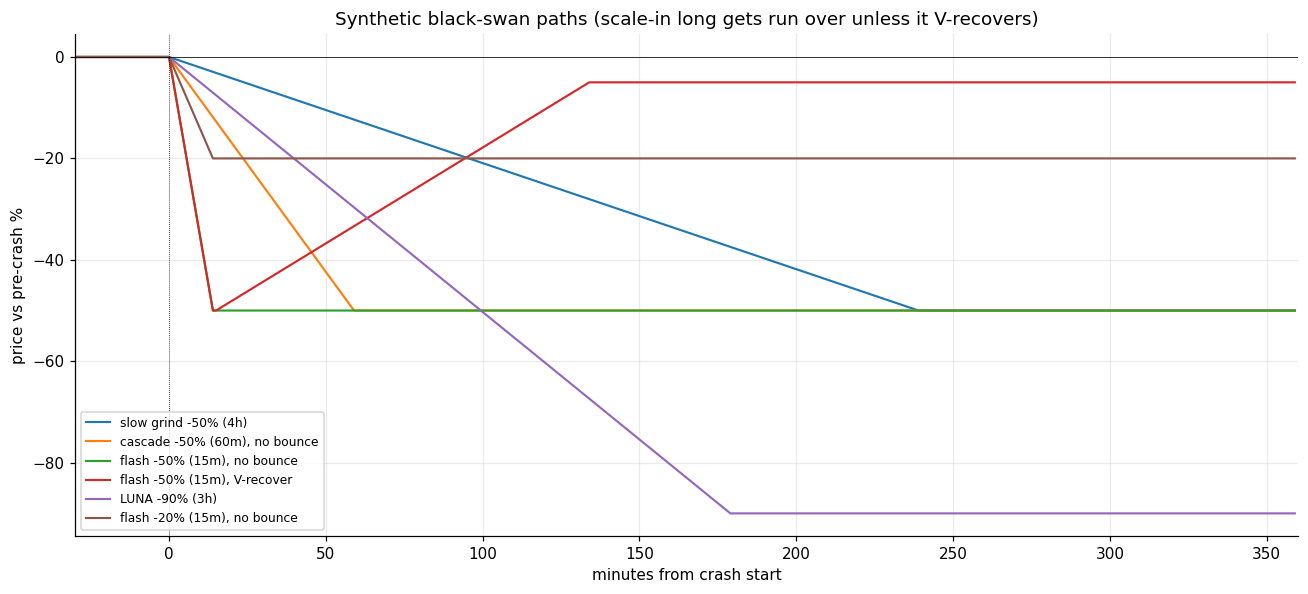

In [4]:
# visualize the scenarios + entry/exit
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5.5))
for k,c in scen.items():
    t=np.arange(len(c))-PRE
    plt.plot(t,(c-1)*100,label=k,lw=1.4)
plt.axvline(0,color="k",lw=.5,ls=":"); plt.axhline(0,color="k",lw=.5)
plt.xlim(-30,360); plt.xlabel("minutes from crash start"); plt.ylabel("price vs pre-crash %")
plt.title("Synthetic black-swan paths (scale-in long gets run over unless it V-recovers)")
plt.legend(fontsize=8); show("08_black_swan")

## 4. Вероятность — честная оценка (markdown, не из наших данных)

Наши данные = **2024-01 … 2026-04**. В этом окне НЕ БЫЛО ни одного системного
каскада крипторынка. Крупные исторические лебеди — все ВНЕ выборки:

| Событие | Когда | Глубина/скорость | В наших данных? |
|---|---|---|---|
| COVID-крах | мар-2020 | BTC −50% за ~1 день | НЕТ |
| Май-2021 делеверидж | май-2021 | −50% за дни | НЕТ |
| LUNA/UST коллапс | май-2022 | −99% за дни (одна монета −100%) | НЕТ |
| FTX | ноя-2022 | −25% рынок, отдельные −100% | НЕТ |
| Yen-carry unwind | авг-2024 | крипто −15..20% за день | частично (край данных) |

**Базовая частота:** крупный системный каскад в крипте случается примерно
**раз в 1.5–2 года** (грубо, по короткой истории 2017-2025). Внутриминутные
flash-краши на ОТДЕЛЬНЫХ монетах (тонкие альты, делистинги, оракул-сбои) —
существенно чаще, несколько раз в год.

**Что это значит для алгоритма:**
- Наш реализованный maxDD −6% — это **нижняя граница**, выборка не содержит худшего.
- В затяжном каскаде scale-in грузит нас у верха (10 траншей в первые 30 мин), стопа
  нет → теряем ~глубину движения по МНОГИМ монетам разом. Один день лебедя может
  стоить десятки % капитала даже на 1x (см. таблицу).
- **Плечо = разорение:** на 2x ~−40% движение ликвидирует, на 5x ~−16%. В каскаде
  это гарантированный ноль. Подтверждает запрет на плечо из SESSION_HANDOFF.
- **Спасает только:** (а) 1x без плеча; (б) hard-catastrophe стоп (жертвуем edge в
  норме ради выживания в хвосте); (в) regime/market-wide kill-switch (не входить,
  когда падает ВЕСЬ рынок разом, а не одна монета).

*Verdict после прогона.*

## VERDICT (iter 08)

**Реализованный DD −6% — это ПОЛ, не потолок.** Выборка 2024-26 НЕ содержит ни
одного системного каскада; все коррелированные дни в ней были V-образными (алго
выигрывал/в ноль: 2025-10-10 +16.7% на 319 дампах; yen-carry 2024-08-05 +0.3%).
Худший реальный кластер: 2025-02-02 −11%/сделку.

**Урон зависит от СКОРОСТИ краха vs наше 30-мин окно доборов:**
- медленный грайнд −50%/4ч → НЕ триггерит (спасает);
- чистый flash −50%/15м → всего −7.5% (доборы усредняются у дна);
- глубокий каскад средней скорости (LUNA −90%/3ч) → **−88% позиции** (10 траншей
  грузятся у верха, потом обвал) — вот где scale-in без стопа убивает;
- каскад −50%/60м → −34.6%.

**Плечо = ликвидация:** движение×плечо ≤ −80% = ноль. На 2x губит ~−40%, на 5x
~−16%. Подтверждает запрет плеча (только 1x).

**Вероятность:** крупный каскад ~раз в 1.5-2 года (COVID/LUNA/FTX — все вне данных);
flash на тонких альтах — несколько раз в год. Реалистичный каскад −30..−50% =
−30..−50% капитала на 1x за событие.

**Митигации (не реализованы):** (1) строго 1x; (2) hard-catastrophe стоп (жертва
edge в норме ради хвоста — единственное, что режет LUNA-сценарий); (3) regime
kill-switch (не входить при market-wide обвале).